# Poprawa modeli

## Walidacja krzyżowa

Stosowanie tych samych danych zarówno do uczenia modelu, jak i do jego oceny stanowi błąd metodologiczny. Model, który jedynie zapamięta etykiety próbek użytych w trakcie treningu, może osiągnąć perfekcyjne wyniki na tych danych, ale nie będzie w stanie trafnie przewidywać dla nowych, nieznanych przykładów. Zjawisko to nazywamy nadmiernym dopasowaniem (overfitting).

Aby temu zapobiec, standardową praktyką w nadzorowanym uczeniu maszynowym jest wydzielenie części dostępnych danych jako zestawu testowego, który służy wyłącznie do oceny ostatecznej skuteczności modelu.

Poniżej przedstawiono schemat blokowy ilustrujący typowy przebieg procesu uczenia modelu z walidacją krzyżową.

<div style="text-align: center;"><img src=".//Images//grid_search_workflow.png" alt="Sklearn" width="400" height="120" style="margin: 10px; "/></div>

Podczas dostrajania modelu, np. przez dobór jego hiperparametrów (czyli ustawień konfiguracyjnych, takich jak ilość drzew w Ranodm Forest), istnieje ryzyko, że zaczniemy nieświadomie dopasowywać model do danych testowych. Gdy zmieniamy parametry w taki sposób, by uzyskać jak najlepsze wyniki na zbiorze testowym, przestaje on pełnić swoją pierwotną funkcję — czyli wiarygodnej oceny zdolności modelu do generalizacji.

Dzieje się tak, ponieważ model „uczy się” nie tylko na danych treningowych, ale pośrednio także na testowych, poprzez nasze decyzje. To zjawisko nazywane jest przeciekiem informacji i prowadzi do zaniżenia błędów, a tym samym do fałszywej oceny skuteczności modelu.

Aby tego uniknąć, wprowadza się trzeci zbiór danych — zestaw walidacyjny. Proces wygląda wówczas następująco:

* Model uczony jest na zbiorze treningowym,
* Hiperparametry są dostrajane w oparciu o wyniki na zbiorze walidacyjnym,
* Dopiero po zakończeniu całego procesu wybierania i strojenia modelu przeprowadza się ostateczną ocenę na zbiorze testowym, który przez cały czas pozostawał „niewidoczny” dla modelu.

Taki podział zapewnia bardziej rzetelną i uczciwą ocenę zdolności modelu do działania na nowych, nieznanych danych.

Wydzielenie danych na trzy części — treningową, walidacyjną i testową — pozwala rzetelnie ocenić model, ale jednocześnie znacząco zmniejsza liczbę próbek dostępnych do nauki. To może prowadzić do sytuacji, w której jakość modelu zależy od konkretnego, przypadkowego podziału danych, co obniża wiarygodność wyników.

Aby temu zaradzić, stosuje się metodę znaną jako walidacja krzyżowa (ang. **cross-validation**, w skrócie **CV**). W tym podejściu nadal pozostawiamy zbiór testowy wyłącznie do końcowej oceny modelu, natomiast zamiast osobnego zbioru walidacyjnego używamy specjalnej procedury wewnątrz zbioru treningowego.

Najczęściej stosowana jest k-krotna walidacja krzyżowa (k-fold CV). Polega ona na tym, że zbiór treningowy dzielimy na k równych części (tzw. „foldy”). Następnie w każdej z k iteracji model trenowany jest na k-1 foldach, s testowany na pozostałym foldzie, który w danej iteracji pełni rolę walidacyjną.
Proces ten powtarza się k razy, za każdym razem zmieniając fold walidacyjny. Końcowym wynikiem jest średnia z k uzyskanych wyników (np. dokładności, F1-score, RMSE itd.).

Choć walidacja krzyżowa bywa bardziej czasochłonna obliczeniowo, to jej największą zaletą jest efektywne wykorzystanie dostępnych danych. Jest to szczególnie ważne w sytuacjach, gdy liczba próbek jest ograniczona — np. w problemach typu wnioskowanie odwrotne, gdzie dostępne dane są trudne lub kosztowne do pozyskania.

<div style="text-align: center;"><img src=".//Images//grid_search_cross_validation.png" alt="CV" width="400" height="120" style="margin: 10px; "/></div>

## Rodzaje korswalidacji

<div style="text-align: center;"><img src=".//Images//iris_1.png" alt="iris" width="400" height="120" style="margin: 10px; "/></div>

In [10]:
%run tools.ipynb

In [11]:
import numpy as np

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

# Załadowanie przykładowych danych (Iris)
X, y = load_iris(return_X_y=True)

# Podział indeksów według klas i wyznaczenie klas
index_groups = split_indices_by_target(y)
class_names = load_iris().target_names

W bibliotece **scikit-learn** istnieje kilka sposobów podziału danych na zbiory treningowe i testowe. Najważniejsze z nich to:  

### Prosty podział (hold-out)
   - Funkcja: **`train_test_split()`** 
   - Dzieli dane jednorazowo na zbiór treningowy i testowy w określonej proporcji.  
   - Parametry: `test_size`, `train_size`, `random_state`, `shuffle` itd.

**Scenariusz:**  
- Masz duży zbiór danych i chcesz szybko przygotować prosty podział na trening i test bez kroswalidacji.  
- Np. trenowanie modelu regresji na dużym zbiorze i szybka ocena na wydzielonym teście.  



In [14]:
# Podział 80% trening, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Rozmiar zbioru treningowego:", X_train.shape)
print("Rozmiar zbioru testowego:", X_test.shape)

Rozmiar zbioru treningowego: (120, 4)
Rozmiar zbioru testowego: (30, 4)


In [15]:
# Liczenie klas
train_counts = count_classes_from_split(y_train, class_names)
test_counts = count_classes_from_split(y_test, class_names)
print(f"Zbiór treningowy: {train_counts}, zbiór testowy: {test_counts}.")

Zbiór treningowy: {'setosa': 40, 'versicolor': 41, 'virginica': 39}, zbiór testowy: {'versicolor': 9, 'setosa': 10, 'virginica': 11}.


Ważne parametry:

**shuffle**: bool, domyślnie = True </br>
Określa, czy dane mają zostać przetasowane przed podziałem.

**stratify**: array-like, domyślnie = None </br>
Jeśli ustawiony, dane zostaną podzielone w sposób stratyfikowany, wykorzystując ten wektor jako etykiety klas.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [18]:
# Liczenie klas
train_counts = count_classes_from_split(y_train, class_names)
test_counts = count_classes_from_split(y_test, class_names)
print(f"Zbiór treningowy: {train_counts}, zbiór testowy: {test_counts}.")

Zbiór treningowy: {'setosa': 40, 'virginica': 40, 'versicolor': 40}, zbiór testowy: {'setosa': 10, 'virginica': 10, 'versicolor': 10}.


### Kroswalidacja (K-Fold Cross Validation)
   - Klasa: **`KFold`**  
   - Dzieli dane na `n_splits` części i iteracyjnie używa innej części jako testowej, a pozostałych jako treningowe.

**Scenariusz:**  
- Chcesz ocenić model na wielu podziałach danych i nie masz problemu z brakiem stratyfikacji.  
- Przydatne do oceny modeli regresyjnych lub klasyfikacyjnych przy danych o równomiernym rozkładzie klas.

<div style="text-align: center;"><img src=".//Images//sphx_glr_plot_cv_indices_006.png" alt="CV" width="400" height="120" style="margin: 10px; "/></div>

In [20]:
from sklearn.model_selection import KFold

In [21]:
kf = KFold(n_splits=5)

for train_index, test_index in kf.split(X):
    draw_index_colorbar([train_index, test_index], title="",  rect_height=0.1)

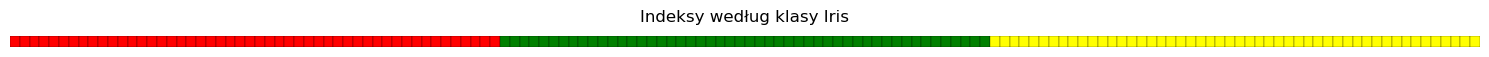

In [22]:
draw_index_colorbar(index_groups, title="Indeksy według klasy Iris", rect_height=0.1, colors=["red", "green", "yellow"])

In [23]:
for train_index, test_index in kf.split(X):
    result_train = count_named_classes_by_indices(y, train_index, class_names=class_names)
    result_test = count_named_classes_by_indices(y, test_index, class_names=class_names)
    print(f"Zbiór treningowy: {result_train}, zbiór testowy: {result_test}.")

Zbiór treningowy: {'setosa': 20, 'versicolor': 50, 'virginica': 50}, zbiór testowy: {'setosa': 30}.
Zbiór treningowy: {'setosa': 30, 'versicolor': 40, 'virginica': 50}, zbiór testowy: {'setosa': 20, 'versicolor': 10}.
Zbiór treningowy: {'setosa': 50, 'versicolor': 20, 'virginica': 50}, zbiór testowy: {'versicolor': 30}.
Zbiór treningowy: {'setosa': 50, 'versicolor': 40, 'virginica': 30}, zbiór testowy: {'versicolor': 10, 'virginica': 20}.
Zbiór treningowy: {'setosa': 50, 'versicolor': 50, 'virginica': 20}, zbiór testowy: {'virginica': 30}.


W tym przypadku warto jednak wylosować kolejne części :)

In [25]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X):
    draw_index_colorbar([train_index, test_index], title="",  rect_height=0.1)

In [26]:
for train_index, test_index in kf.split(X):
    result_train = count_named_classes_by_indices(y, train_index, class_names=class_names)
    result_test = count_named_classes_by_indices(y, test_index, class_names=class_names)
    print(f"Zbiór treningowy: {result_train}, zbiór testowy: {result_test}.")

Zbiór treningowy: {'setosa': 40, 'versicolor': 41, 'virginica': 39}, zbiór testowy: {'setosa': 10, 'versicolor': 9, 'virginica': 11}.
Zbiór treningowy: {'setosa': 37, 'versicolor': 40, 'virginica': 43}, zbiór testowy: {'setosa': 13, 'versicolor': 10, 'virginica': 7}.
Zbiór treningowy: {'setosa': 38, 'versicolor': 40, 'virginica': 42}, zbiór testowy: {'setosa': 12, 'versicolor': 10, 'virginica': 8}.
Zbiór treningowy: {'setosa': 42, 'versicolor': 40, 'virginica': 38}, zbiór testowy: {'setosa': 8, 'versicolor': 10, 'virginica': 12}.
Zbiór treningowy: {'setosa': 43, 'versicolor': 39, 'virginica': 38}, zbiór testowy: {'setosa': 7, 'versicolor': 11, 'virginica': 12}.


### Stratyfikowana kroswalidacja (Stratified K-Fold)
   - Klasa: **`StratifiedKFold`**  
   - Jak `KFold`, ale dodatkowo zapewnia utrzymanie proporcji klas w każdym podziale (ważne dla problemów klasyfikacyjnych).

**Scenariusz:**  
- Klasyfikacja, w której klasy są nierównomierne i chcesz zachować proporcje klas w każdym foldzie.  
- Np. klasyfikacja medyczna, gdzie klasa „chory” jest znacznie rzadsza od „zdrowy”. 

<div style="text-align: center;"><img src=".//Images//sphx_glr_plot_cv_indices_009.png" alt="CV" width="400" height="120" style="margin: 10px; "/></div>

In [28]:
from sklearn.model_selection import StratifiedKFold

In [29]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in skf.split(X, y):
    draw_index_colorbar([train_index, test_index], title="",  rect_height=0.1)

In [30]:
for train_index, test_index in skf.split(X, y):
    result_train = count_named_classes_by_indices(y, train_index, class_names=class_names)
    result_test = count_named_classes_by_indices(y, test_index, class_names=class_names)
    print(f"Zbiór treningowy: {result_train}, zbiór testowy: {result_test}.")

Zbiór treningowy: {'setosa': 40, 'versicolor': 40, 'virginica': 40}, zbiór testowy: {'setosa': 10, 'versicolor': 10, 'virginica': 10}.
Zbiór treningowy: {'setosa': 40, 'versicolor': 40, 'virginica': 40}, zbiór testowy: {'setosa': 10, 'versicolor': 10, 'virginica': 10}.
Zbiór treningowy: {'setosa': 40, 'versicolor': 40, 'virginica': 40}, zbiór testowy: {'setosa': 10, 'versicolor': 10, 'virginica': 10}.
Zbiór treningowy: {'setosa': 40, 'versicolor': 40, 'virginica': 40}, zbiór testowy: {'setosa': 10, 'versicolor': 10, 'virginica': 10}.
Zbiór treningowy: {'setosa': 40, 'versicolor': 40, 'virginica': 40}, zbiór testowy: {'setosa': 10, 'versicolor': 10, 'virginica': 10}.


### Losowy podział w kroswalidacji (ShuffleSplit)
   - Klasa: **`ShuffleSplit`** 
   - Wielokrotnie dzieli dane na zbiór treningowy i testowy przez losowe próbkowanie bez zależności między foldami.

Działanie: 
* Przy każdej iteracji dane są losowo mieszane (shuffle).
* Następnie wybierany jest określony procent danych do zbioru treningowego i testowego.

Ważne paramatry:

**n_splits**	Liczba losowych podziałów do wykonania (domyślnie 10).


**Scenariusz:**  
- Masz duży zbiór danych i chcesz wielokrotnie testować model na różnych losowych próbkach, bez potrzeby foldów deterministycznych.  
- Przydatne przy testach stabilności modelu.

<div style="text-align: center;"><img src=".//Images//sphx_glr_plot_cv_indices_008.png" alt="CV" width="400" height="120" style="margin: 10px; "/></div>

In [32]:
from sklearn.model_selection import ShuffleSplit

In [33]:
ss = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

for train_index, test_index in ss.split(X):
    draw_index_colorbar([train_index, test_index], title="",  rect_height=0.1)

In [34]:
for train_index, test_index in ss.split(X, y):
    result_train = count_named_classes_by_indices(y, train_index, class_names=class_names)
    result_test = count_named_classes_by_indices(y, test_index, class_names=class_names)
    print(f"Zbiór treningowy: {result_train}, zbiór testowy: {result_test}.")

Zbiór treningowy: {'setosa': 40, 'versicolor': 41, 'virginica': 39}, zbiór testowy: {'versicolor': 9, 'setosa': 10, 'virginica': 11}.
Zbiór treningowy: {'setosa': 36, 'versicolor': 44, 'virginica': 40}, zbiór testowy: {'versicolor': 6, 'setosa': 14, 'virginica': 10}.
Zbiór treningowy: {'setosa': 45, 'virginica': 41, 'versicolor': 34}, zbiór testowy: {'versicolor': 16, 'virginica': 9, 'setosa': 5}.
Zbiór treningowy: {'setosa': 43, 'virginica': 36, 'versicolor': 41}, zbiór testowy: {'versicolor': 9, 'virginica': 14, 'setosa': 7}.
Zbiór treningowy: {'versicolor': 40, 'virginica': 39, 'setosa': 41}, zbiór testowy: {'virginica': 11, 'versicolor': 10, 'setosa': 9}.


### Stratyfikowany losowy podział (StratifiedShuffleSplit)
   - Klasa: `StratifiedShuffleSplit`  
   - Jak `ShuffleSplit`, ale zapewnia zachowanie proporcji klas w każdym podziale.

**Scenariusz:**  
- Klasyfikacja z niezrównoważonymi klasami, potrzebujesz wielu losowych podziałów z zachowaniem proporcji klas.  
- Np. testowanie klasyfikatora fraud detection (rzadkie przypadki oszustw).

<div style="text-align: center;"><img src=".//Images//sphx_glr_plot_cv_indices_012.png" alt="CV" width="400" height="120" style="margin: 10px; "/></div>

In [36]:
from sklearn.model_selection import StratifiedShuffleSplit

In [37]:
sss = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

for train_index, test_index in sss.split(X, y):
    draw_index_colorbar([train_index, test_index], title="",  rect_height=0.1)

In [38]:
for train_index, test_index in sss.split(X, y):
    result_train = count_named_classes_by_indices(y, train_index, class_names=class_names)
    result_test = count_named_classes_by_indices(y, test_index, class_names=class_names)
    print(f"Zbiór treningowy: {result_train}, zbiór testowy: {result_test}.")

Zbiór treningowy: {'setosa': 40, 'virginica': 40, 'versicolor': 40}, zbiór testowy: {'setosa': 10, 'virginica': 10, 'versicolor': 10}.
Zbiór treningowy: {'versicolor': 40, 'setosa': 40, 'virginica': 40}, zbiór testowy: {'versicolor': 10, 'virginica': 10, 'setosa': 10}.
Zbiór treningowy: {'versicolor': 40, 'setosa': 40, 'virginica': 40}, zbiór testowy: {'virginica': 10, 'setosa': 10, 'versicolor': 10}.
Zbiór treningowy: {'versicolor': 40, 'virginica': 40, 'setosa': 40}, zbiór testowy: {'versicolor': 10, 'setosa': 10, 'virginica': 10}.
Zbiór treningowy: {'versicolor': 40, 'virginica': 40, 'setosa': 40}, zbiór testowy: {'virginica': 10, 'versicolor': 10, 'setosa': 10}.


### Grupowy KFold (GroupKFold)
   - Klasa: `GroupKFold`  
   - Dzieli dane na podstawie grup (np. dane z tego samego pacjenta lub jednostki nigdy nie trafią zarówno do treningu, jak i testu w tym samym foldzie).

**Scenariusz:**  
- Dane są zorganizowane w grupy, które nie mogą się mieszać między treningiem a testem (np. pacjenci, maszyny, serie pomiarowe).  
- Np. modele predykcji biomarkerów na danych z badań klinicznych — dane od jednego pacjenta nie mogą trafić do treningu i testu jednocześnie.

UWAGA: liczba `n_splits` nie może być większa od liczby grup.

<div style="text-align: center;"><img src=".//Images//sphx_glr_plot_cv_indices_007.png" alt="CV" width="400" height="120" style="margin: 10px; "/></div>

In [40]:
from sklearn.model_selection import GroupKFold

In [41]:
# Przykładowe grupy (np. kwiaty z jednego ogródka :D)
groups = np.array([1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 5] * 10)

In [42]:
gkf = GroupKFold(n_splits=4)

for train_index, test_index in gkf.split(X, y, groups=groups):
    draw_index_colorbar([train_index, test_index], title="",  rect_height=0.1)

In [43]:
for train_index, test_index in gkf.split(X, y, groups=groups):
    result_train = count_named_classes_by_indices(y, train_index, class_names=class_names)
    result_test = count_named_classes_by_indices(y, test_index, class_names=class_names)
    print(f"Zbiór treningowy: {result_train}, zbiór testowy: {result_test}.")

Zbiór treningowy: {'setosa': 29, 'versicolor': 32, 'virginica': 29}, zbiór testowy: {'setosa': 21, 'versicolor': 18, 'virginica': 21}.
Zbiór treningowy: {'setosa': 41, 'versicolor': 40, 'virginica': 39}, zbiór testowy: {'setosa': 9, 'versicolor': 10, 'virginica': 11}.
Zbiór treningowy: {'setosa': 41, 'versicolor': 38, 'virginica': 41}, zbiór testowy: {'setosa': 9, 'versicolor': 12, 'virginica': 9}.
Zbiór treningowy: {'setosa': 39, 'versicolor': 40, 'virginica': 41}, zbiór testowy: {'setosa': 11, 'versicolor': 10, 'virginica': 9}.


### Losowy podział z zachowaniem grup (GroupShuffleSplit)
- Klasa: **`GroupShuffleSplit`**
- Dzieli dane **losowo** na zbiór treningowy i testowy, ale z zachowaniem zasady, że próbki należące do tej samej **grupy** trafiają wyłącznie do jednego z tych zbiorów. W przeciwieństwie do `GroupKFold`, podział jest jednorazowy (lub powtarzany losowo `n_splits` razy), a nie deterministyczny i sekwencyjny.

**Scenariusz:**  
- Masz dane podzielone na grupy (np. pacjenci, urządzenia pomiarowe, serie eksperymentów), ale zamiast wielu foldów potrzebujesz jednorazowego lub losowo powtarzanego podziału na trening i test.  
- Idealne do **eksperymentów z walidacją na poziomie grup**, gdy zależy Ci na losowości, ale chcesz uniknąć przecieku danych między grupami.  
- Przykład: analiza prób środowiskowych zebranych z różnych lokalizacji — chcesz, aby dane z jednej lokalizacji nie pojawiały się zarówno w treningu, jak i w teście, ale zależy Ci na losowym rozdziale lokalizacji.

<div style="text-align: center;"><img src=".//Images//sphx_glr_plot_cv_indices_011.png" alt="CV" width="400" height="120" style="margin: 10px; "/></div>

In [45]:
from sklearn.model_selection import GroupShuffleSplit

In [46]:
# Przykładowe grupy (np. kwiaty z jednego ogródka :D)
groups = np.array([1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 5] * 10)

In [47]:
gss = GroupShuffleSplit(n_splits=3, test_size=0.2, random_state=42) # split 1: seed, split 2: seed+1, split 3: seed+2 itp.

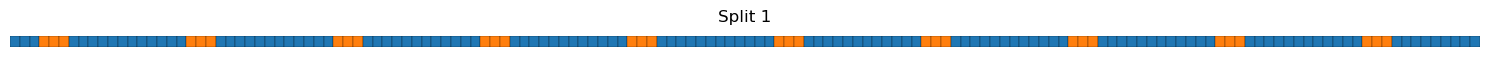

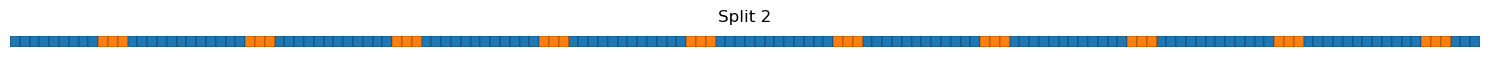

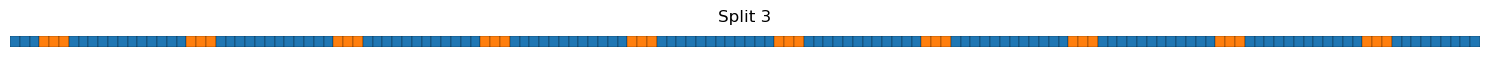

In [48]:
for i, (train_idx, test_idx) in enumerate(gss.split(X, y, groups=groups)):
    draw_index_colorbar([train_idx, test_idx], title=f"Split {i+1}", rect_height=0.1)

In [49]:
for train_index, test_index in gss.split(X, y, groups=groups):
    result_train = count_named_classes_by_indices(y, train_index, class_names=class_names)
    result_test = count_named_classes_by_indices(y, test_index, class_names=class_names)
    print(f"Zbiór treningowy: {result_train}, zbiór testowy: {result_test}.")

Zbiór treningowy: {'setosa': 39, 'versicolor': 40, 'virginica': 41}, zbiór testowy: {'setosa': 11, 'versicolor': 10, 'virginica': 9}.
Zbiór treningowy: {'setosa': 41, 'versicolor': 40, 'virginica': 39}, zbiór testowy: {'setosa': 9, 'versicolor': 10, 'virginica': 11}.
Zbiór treningowy: {'setosa': 39, 'versicolor': 40, 'virginica': 41}, zbiór testowy: {'setosa': 11, 'versicolor': 10, 'virginica': 9}.


In [50]:
# Podział
for train_idx, test_idx in gss.split(X, y, groups=groups):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    groups_train, groups_test = groups[train_idx], groups[test_idx]
    # Wyniki
    print("Liczba próbek w zbiorze treningowym:", len(train_idx))
    print("Liczba próbek w zbiorze testowym:", len(test_idx))
    print("Unikalne grupy treningowe:", np.unique(groups_train))
    print("Unikalne grupy testowe:", np.unique(groups_test))
    print("Czy grupy się przecinają:", not(set(groups_train).isdisjoint(set(groups_test))))
    print("====================================================================")

Liczba próbek w zbiorze treningowym: 120
Liczba próbek w zbiorze testowym: 30
Unikalne grupy treningowe: [1 3 4 5]
Unikalne grupy testowe: [2]
Czy grupy się przecinają: False
Liczba próbek w zbiorze treningowym: 120
Liczba próbek w zbiorze testowym: 30
Unikalne grupy treningowe: [1 2 3 5]
Unikalne grupy testowe: [4]
Czy grupy się przecinają: False
Liczba próbek w zbiorze treningowym: 120
Liczba próbek w zbiorze testowym: 30
Unikalne grupy treningowe: [1 3 4 5]
Unikalne grupy testowe: [2]
Czy grupy się przecinają: False


### Grupowo-stratyfikowany KFold (StratifiedGroupKFold)
- Klasa: **`StratifiedGroupKFold`**  
- Łączy zalety **stratyfikacji** (zachowanie proporcji klas) oraz **podziału grupowego** (dane z tej samej grupy nie trafiają do różnych foldów).

**Scenariusz:**  
- Dane są zorganizowane w **grupy** (np. pacjenci, maszyny, serie pomiarowe), ale **etykiety klasyfikacyjne są przypisane do próbek**.  
- Chcesz podzielić dane w sposób:
  1. Stratyfikowany — każda klasa występuje w podobnych proporcjach w każdym foldzie,
  2. Grupowy — żadna grupa nie trafia jednocześnie do treningu i testu.

Idealny, gdy chcesz trenować klasyfikator z zachowaniem proporcji klas, ale z wykluczeniem przecieku danych między grupami.

<div style="text-align: center;"><img src=".//Images//sphx_glr_plot_cv_indices_010.png" alt="CV" width="400" height="120" style="margin: 10px; "/></div>

In [52]:
from sklearn.model_selection import StratifiedGroupKFold

In [53]:
# Przykładowe grupy (np. kwiaty z jednego ogródka :D)
groups = np.array([1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 5] * 10)

In [54]:
sgkf = StratifiedGroupKFold(n_splits=5)

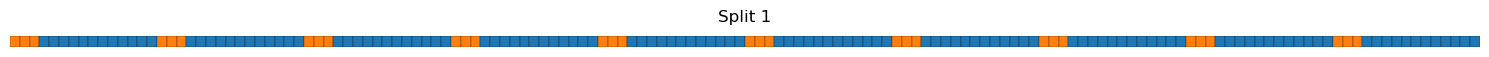

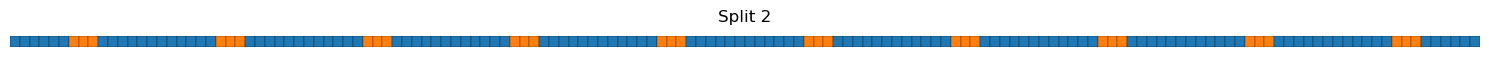

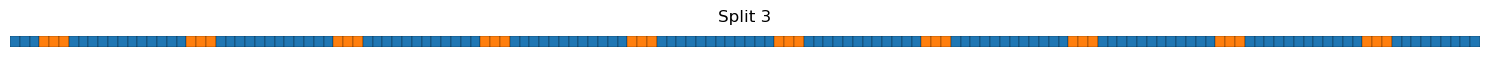

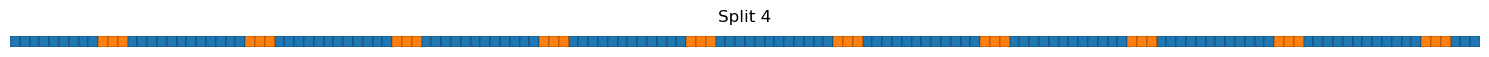

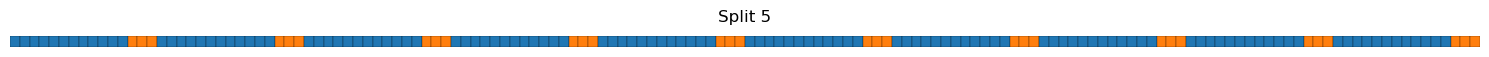

In [55]:
for i, (train_idx, test_idx) in enumerate(sgkf.split(X, y, groups=groups)):
    draw_index_colorbar([train_idx, test_idx], title=f"Split {i+1}", rect_height=0.1)

In [56]:
for train_index, test_index in sgkf.split(X, y, groups=groups):
    result_train = count_named_classes_by_indices(y, train_index, class_names=class_names)
    result_test = count_named_classes_by_indices(y, test_index, class_names=class_names)
    print(f"Zbiór treningowy: {result_train}, zbiór testowy: {result_test}.")

Zbiór treningowy: {'setosa': 38, 'versicolor': 41, 'virginica': 41}, zbiór testowy: {'setosa': 12, 'versicolor': 9, 'virginica': 9}.
Zbiór treningowy: {'setosa': 41, 'versicolor': 38, 'virginica': 41}, zbiór testowy: {'setosa': 9, 'versicolor': 12, 'virginica': 9}.
Zbiór treningowy: {'setosa': 39, 'versicolor': 40, 'virginica': 41}, zbiór testowy: {'setosa': 11, 'versicolor': 10, 'virginica': 9}.
Zbiór treningowy: {'setosa': 41, 'versicolor': 40, 'virginica': 39}, zbiór testowy: {'setosa': 9, 'versicolor': 10, 'virginica': 11}.
Zbiór treningowy: {'setosa': 41, 'versicolor': 41, 'virginica': 38}, zbiór testowy: {'setosa': 9, 'versicolor': 9, 'virginica': 12}.


In [57]:
for fold, (train_idx, test_idx) in enumerate(sgkf.split(X, y, groups)):
    print(f"Fold {fold + 1}")
    print("  Grupy treningowe:", np.unique(groups[train_idx]))
    print("  Grupy testowe   :", np.unique(groups[test_idx]))   
    print("  Rozkład klas w treningu:", np.bincount(y[train_idx]))
    print("  Rozkład klas w teście:", np.bincount(y[test_idx]))
    print()

Fold 1
  Grupy treningowe: [2 3 4 5]
  Grupy testowe   : [1]
  Rozkład klas w treningu: [38 41 41]
  Rozkład klas w teście: [12  9  9]

Fold 2
  Grupy treningowe: [1 2 4 5]
  Grupy testowe   : [3]
  Rozkład klas w treningu: [41 38 41]
  Rozkład klas w teście: [ 9 12  9]

Fold 3
  Grupy treningowe: [1 3 4 5]
  Grupy testowe   : [2]
  Rozkład klas w treningu: [39 40 41]
  Rozkład klas w teście: [11 10  9]

Fold 4
  Grupy treningowe: [1 2 3 5]
  Grupy testowe   : [4]
  Rozkład klas w treningu: [41 40 39]
  Rozkład klas w teście: [ 9 10 11]

Fold 5
  Grupy treningowe: [1 2 3 4]
  Grupy testowe   : [5]
  Rozkład klas w treningu: [41 41 38]
  Rozkład klas w teście: [ 9  9 12]



### Leave-One-Out (LOO) 
   - Klasa: **`LeaveOneOut`**  
   - Tworzy tyle foldów, ile jest próbek, za każdym razem używając jednej próbki jako testowej.

**Scenariusz:**  
- Masz bardzo mały zbiór danych (np. kilkanaście–kilkadziesiąt obserwacji) i chcesz maksymalnie wykorzystać dane do treningu.  
- Np. eksperymentalne dane laboratoryjne, gdzie próbek jest bardzo niewiele.

In [59]:
from sklearn.model_selection import LeaveOneOut

In [60]:
loo = LeaveOneOut()

max_iter = 20
counter = 0

print(f"Dla {max_iter} iteracji:")

for train_index, test_index in loo.split(X):
    draw_index_colorbar([train_index, test_index], title="",  rect_height=0.1)
    counter += 1
    if counter >= max_iter:
        break

Dla 20 iteracji:


### Leave-P-Out (LPO) 
   - Klasa: **`LeavePOut`**  
   - Analogicznie do LOO, ale pozostawia `p` próbek jako testowych.  

**Scenariusz:**  
- Bardzo mały zbiór danych, chcesz sprawdzić wszystkie możliwe kombinacje pozostawienia `p` próbek jako testu.  
- Np. analiza wytrzymałości modelu na minimalnych danych testowych lub pełne przeszukiwanie kombinacji przy zbiorach o rozmiarze 10–20. 

In [62]:
from sklearn.model_selection import LeavePOut

In [63]:
lpo = LeavePOut(p=2)

print(f"Dla zmniejszonego zbioru:")

for train_index, test_index in lpo.split(X[:8]): #<--- zmniejszona liczba
    draw_index_colorbar([train_index, test_index], title="",  rect_height=0.1)

Dla zmniejszonego zbioru:


### TimeSeriesSplit
- Klasa: **`TimeSeriesSplit`**  
- Służy do dzielenia danych szeregów czasowych na zbiór treningowy i testowy, **z zachowaniem kolejności czasowej**.  
- W przeciwieństwie do innych metod (np. `KFold`), **dane nie są mieszane ani dzielone losowo**.

**Scenariusz:**  
- Dane pochodzą z pomiarów czasowych, np. ceny akcji, dane pogodowe, sygnały biologiczne, produkcja godzinowa itp.  
- Model powinien być trenowany na przeszłości, a testowany na przyszłości – jak w rzeczywistych prognozach.  
- Przykład: uczysz model na danych od stycznia do maja, a testujesz na czerwcu.  
- Idealny do problemów prognozowania, detekcji anomalii w czasie, modeli predykcji w systemach rzeczywistych.

<div style="text-align: center;"><img src=".//Images//sphx_glr_plot_cv_indices_013.png" alt="CV" width="400" height="120" style="margin: 10px; "/></div>

In [65]:
# Przykład deklaracji
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=3)

# Podsumowanie metod podziału danych (scikit-learn)

| Metoda                     | Losowość | Zachowuje klasy | Zachowuje grupy | Kolejność czasowa | Typ podziału                                |
|----------------------------|----------|------------------|------------------|--------------------|----------------------------------------------|
| **Hold-out**               | ✅       | Opcjonalnie      | ❌               | ❌                 | Jednorazowy podział                          |
| **KFold**                  | ❌       | ❌               | ❌               | ❌                 | K-krotna walidacja                           |
| **StratifiedKFold**        | ❌       | ✅               | ❌               | ❌                 | K-krotna walidacja z zachowaniem klas        |
| **ShuffleSplit**           | ✅       | ❌               | ❌               | ❌                 | Losowy wielokrotny podział                   |
| **StratifiedShuffleSplit** | ✅       | ✅               | ❌               | ❌                 | Losowy wielokrotny podział z klasami         |
| **GroupKFold**             | ❌       | ❌               | ✅               | ❌                 | K-krotna walidacja z rozdzieleniem grup      |
| **GroupShuffleSplit**      | ✅       | ❌               | ✅               | ❌                 | Losowy podział grupowy                       |
| **StratifiedGroupKFold**   | ❌       | ✅               | ✅               | ❌                 | K-krotna walidacja: klasy + grupy            |
| **TimeSeriesSplit**        | ❌       | ❌               | ❌               | ✅                 | K-krotna walidacja czasowa (szereg danych)   |
| **LeaveOneOut (LOO)**      | ❌       | ❌               | ❌               | ❌                 | Każda próbka osobno w teście                 |
| **LeavePOut (LPO)**        | ❌       | ❌               | ❌               | ❌                 | Wszystkie możliwe kombinacje `p` próbek testowych |

---

**Legenda**:
- **Losowość** – czy podział danych jest losowy  
- **Zachowuje klasy** – czy proporcje klas są utrzymywane (stratyfikacja)  
- **Zachowuje grupy** – czy dane z jednej grupy nie są dzielone między trening i test  
- **Kolejność czasowa** – czy zachowywana jest chronologia obserwacji  
- **Typ podziału** – opis charakterystyki danej metody

# Przykłady

## Przykład 1: Prosty podział (Hold-Out) na zbiorze Iris

<div style="text-align: center;"><img src=".//Images//iris_2.png" alt="iris" width="400" height="120" style="margin: 10px; "/></div>

**Scenariusz:**  
Masz klasyczny zbiór danych Iris z dobrze zbalansowanymi klasami i 150 obserwacjami. Model ma posłużyć do podstawowej klasyfikacji kwiatów na trzy gatunki. Dane są niewielkie, ale podział typu *hold-out* jest często używany do szybkiego sprawdzenia jakości modelu bez skomplikowanej walidacji.  

**Uzasadnienie metody:**  
- Hold-out stosujemy przy małych i średnich zbiorach danych, gdy chcemy szybko sprawdzić jakość predykcji, bez potrzeby obliczeniowo kosztownej kroswalidacji.  
- Prosty podział pozwala też łatwo przeprowadzać porównania różnych modeli na tym samym podziale.  

In [70]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Załaduj dane
X, y = load_iris(return_X_y=True)

# Podział danych na zbiór treningowy i testowy (30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)

# Budowa modelu
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predykcja i ocena
y_pred = model.predict(X_test)
print(f"Dokładność (hold-out): {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Dokładność (hold-out): 0.9556
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       0.91      0.91      0.91        11
           2       0.94      0.94      0.94        18

    accuracy                           0.96        45
   macro avg       0.95      0.95      0.95        45
weighted avg       0.96      0.96      0.96        45



## Przykład 2: K-Fold na zbiorze Breast Cancer

<div style="text-align: center;"><img src=".//Images//Breast Cancer Wisconsin.png" alt="iris" width="400" height="120" style="margin: 10px; "/></div>

**Scenariusz:**  
Zbiór danych Breast Cancer Wisconsin (569 próbek, 30 cech). Problem klasyfikacji (łagodny/złośliwy). Dane są większe, ale ich rozkład jest stosunkowo równomierny. Zamiast przypadkowego podziału, chcemy sprawdzić stabilność modelu w kilku różnych losowych podziałach.  

**Uzasadnienie metody:**  
- K-Fold dobrze sprawdza się w ocenie modelu na różnych częściach danych, gdy chcemy mieć powtarzalną ocenę.  
- Używamy klasycznego K-Fold bez stratyfikacji, bo klasy są zbalansowane.  
- Średnia dokładność i rozrzut wyników dają szerszy obraz jakości modelu.  

In [72]:
# WERSJA 1
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

X, y = load_breast_cancer(return_X_y=True)
model = LogisticRegression(max_iter=5000)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []

for train_idx, test_idx in kf.split(X):
    model.fit(X[train_idx], y[train_idx])
    y_pred = model.predict(X[test_idx])
    scores.append(accuracy_score(y[test_idx], y_pred))

print(f"Średnia dokładność (K-Fold): {np.mean(scores):.4f}")
print(f"Odchylenie standardowe: {np.std(scores):.4f}")

Średnia dokładność (K-Fold): 0.9507
Odchylenie standardowe: 0.0191


In [73]:
# WERSJA 2 - wykorzystanie cross_val_score
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np

X, y = load_breast_cancer(return_X_y=True)
model = LogisticRegression(max_iter=5000)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# cross_val_score domyślnie używa scoring='accuracy'
scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

print(f"Średnia dokładność (K-Fold): {np.mean(scores):.4f}")
print(f"Odchylenie standardowe: {np.std(scores):.4f}")

Średnia dokładność (K-Fold): 0.9507
Odchylenie standardowe: 0.0191


In [74]:
# WERSJA 3 - kilka metryk
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LogisticRegression
import numpy as np

from sklearn.metrics import make_scorer, accuracy_score, f1_score, roc_auc_score

X, y = load_breast_cancer(return_X_y=True)
model = LogisticRegression(max_iter=5000)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# cross_validate pozwala na wiele metryk
scoring = ['accuracy', 'f1', 'roc_auc']

results = cross_validate(model, X, y, cv=kf, scoring=scoring, return_train_score=False)

# Wyświetlenie średnich i odchyleń standardowych
for metric in scoring:
    mean = np.mean(results[f'test_{metric}'])
    std = np.std(results[f'test_{metric}'])
    print(f"{metric.capitalize():<10} Średnia: {mean:.4f}, Odchylenie: {std:.4f}")

Accuracy   Średnia: 0.9507, Odchylenie: 0.0191
F1         Średnia: 0.9607, Odchylenie: 0.0165
Roc_auc    Średnia: 0.9902, Odchylenie: 0.0102


## Przykład 3: Stratified K-Fold na zbiorze Wine

<div style="text-align: center;"><img src=".//Images//wine.png" alt="iris" width="400" height="120" style="margin: 10px; "/></div>

**Scenariusz:**  
Zbiór danych Wine (178 obserwacji, 3 klasy). Mamy nierównomierny rozkład klas, więc standardowy K-Fold mógłby zakłócić proporcje klas w foldach. Stosujemy więc StratifiedKFold, aby w każdym foldzie zachować rozkład klas podobny do oryginalnego.  

**Uzasadnienie metody:**  
- Stratified K-Fold jest kluczowy, gdy klasy są nierównomierne i chcemy uniknąć sytuacji, że fold testowy będzie miał tylko jeden rodzaj klasy lub dominację jednej klasy.  
- Zapewnia stabilniejsze i bardziej wiarygodne wyniki klasyfikacji.  

In [76]:
from sklearn.datasets import load_wine
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np

X, y = load_wine(return_X_y=True)
model = DecisionTreeClassifier(random_state=42)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

print(f"Średnia dokładność (K-Fold): {np.mean(scores):.4f}")
print(f"Odchylenie standardowe: {np.std(scores):.4f}")

Średnia dokładność (K-Fold): 0.8763
Odchylenie standardowe: 0.0453


##  Przykład 4: ShuffleSplit na zbiorze diabetes (regresja)

<div style="text-align: center;"><img src=".//Images//diabetes.png" alt="diabetes" width="400" height="120" style="margin: 10px; "/></div>

**Scenariusz:**  
Zbiór danych **Diabetes** to klasyczny zbiór do regresji (442 obserwacje). Chcemy wielokrotnie losowo dzielić dane i sprawdzać stabilność modelu regresyjnego.  

**Uzasadnienie metody:**  
- `ShuffleSplit` pozwala przeprowadzić wielokrotne losowe podziały na trening i test bez sztywnego podziału na foldy.  
- Przydaje się, gdy chcemy sprawdzić, jak model radzi sobie na różnych losowych wariantach danych.  

In [78]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import ShuffleSplit, cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

X, y = load_diabetes(return_X_y=True)
model = LinearRegression()

ss = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Uwaga: scikit-learn używa negatywnego MSE (takie są wymagania interfejsu)
neg_mse_scores = cross_val_score(model, X, y, cv=ss, scoring='neg_mean_squared_error')

# Konwersja na dodatnie MSE
mse_scores = -neg_mse_scores

print(f"Średni błąd średniokwadratowy (ShuffleSplit): {np.mean(mse_scores):.4f}")
print(f"Odchylenie standardowe: {np.std(mse_scores):.4f}")

Średni błąd średniokwadratowy (ShuffleSplit): 2924.5350
Odchylenie standardowe: 302.6783


# Źródła
Walidacja:
* https://scikit-learn.org/stable/modules/cross_validation.html
* https://scikit-learn.org/stable/auto_examples/model_selection/plot_cv_indices.html